# ADCC Rating Engine Analysis

This notebook analyses and compares the outputs of two rating engines applied to ADCC historical match data:
- **Elo** - match-by-match updates with a dynamic K-factor
- **Glicko-2** - period-based updates (yearly) with rating deviation (RD) and volatility

Run both engines first to generate the CSV outputs before executing this notebook:
```
python adcc_elo_engine.py
python adcc_elo_with_glicko.py
```

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [9]:
# Raw match data
raw = pd.read_csv('adcc_historical_data.csv', delimiter=';')

# Elo engine outputs
elo_matches  = pd.read_csv('elo-engine-result/bjj_matches_with_elo.csv')
elo_current  = pd.read_csv('elo-engine-result/current_fighters_elo.csv')
elo_peak     = pd.read_csv('elo-engine-result/peak_elo.csv')

# Glicko-2 engine outputs
g2_matches   = pd.read_csv('glicko2-engine-result/bjj_matches_with_glicko.csv')
g2_current   = pd.read_csv('glicko2-engine-result/current_fighters_glicko.csv')
g2_peak      = pd.read_csv('glicko2-engine-result/peak_fighters_glicko.csv')

print(f'Total matches:  {len(raw)}')
print(f'Unique fighters: {pd.concat([raw["winner_name"], raw["loser_name"]]).nunique()}')
print(f'Years covered:  {raw["year"].min()} – {raw["year"].max()}')

Total matches:  1028
Unique fighters: 614
Years covered:  1998 – 2022


## 2. Dataset Overview

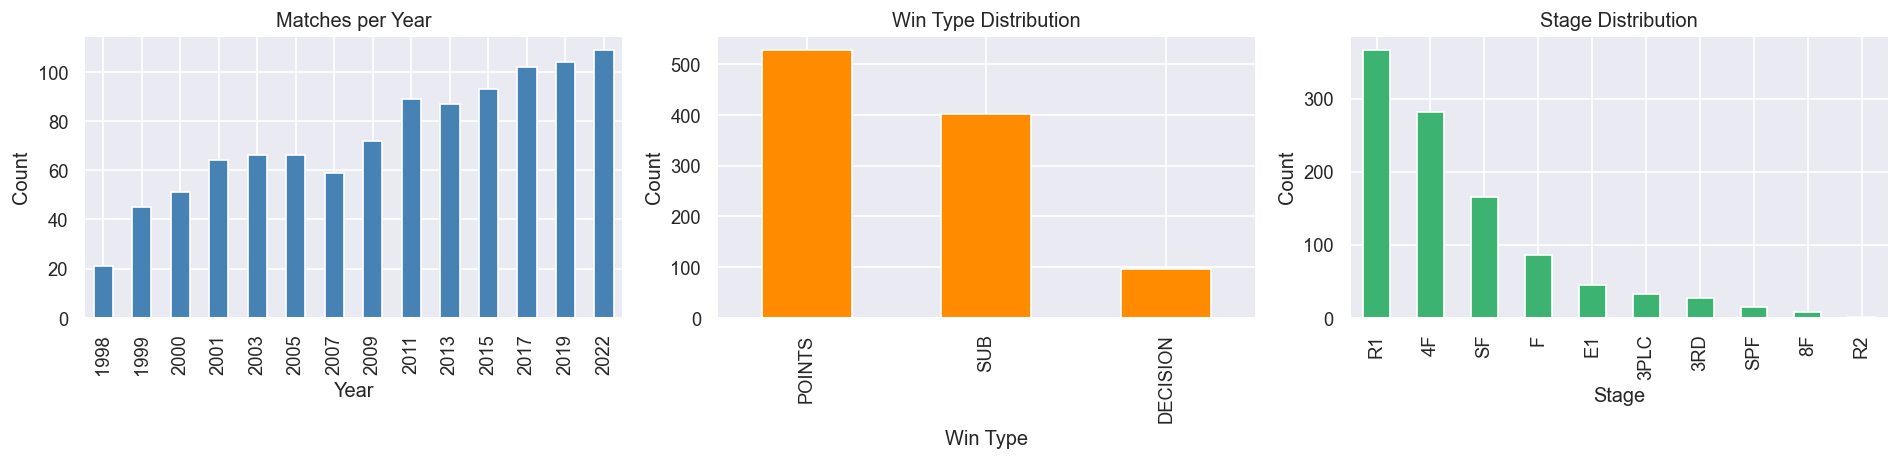

In [10]:
# Matches per year
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

raw.groupby('year').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Matches per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Win type distribution
def classify(x):
    if 'SUB' in str(x): return 'SUB'
    if 'DECISION' in str(x): return 'DECISION'
    return 'POINTS'

raw['win_type_clean'] = raw['win_type'].apply(classify)
raw['win_type_clean'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Win Type Distribution')
axes[1].set_xlabel('Win Type')
axes[1].set_ylabel('Count')

# Stage distribution
raw['stage'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Stage Distribution')
axes[2].set_xlabel('Stage')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Elo Engine - Top Rankings

In [11]:
print('=== Top 20 Current Elo Ratings ===')
display(elo_current.head(20))

print('\n=== Top 20 Peak Elo Ratings ===')
display(elo_peak.head(20))

=== Top 20 Current Elo Ratings ===


,Fighter,Elo Rating
0,Gordon Ryan,1327.69
1,Andre Galvao,1278.39
2,Marcelo Garcia,1263.64
3,Rubens Charles,1256.34
4,Ricardo Arona,1245.74
5,Roger Gracie,1221.22
6,Marcus Almeida,1209.77
7,Royler Gracie,1207.25
8,Yuri Simoes,1200.51
9,Fabricio Werdum,1198.54



=== Top 20 Peak Elo Ratings ===


,Fighter,Peak Elo
0,Gordon Ryan,1327.69
1,Andre Galvao,1313.01
2,Marcelo Garcia,1274.92
3,Rubens Charles,1256.34
4,Ricardo Arona,1245.74
5,Fabricio Werdum,1230.98
6,Braulio Estima,1230.33
7,Marcus Almeida,1229.23
8,Roger Gracie,1221.22
9,Alexandre Ribeiro,1220.21


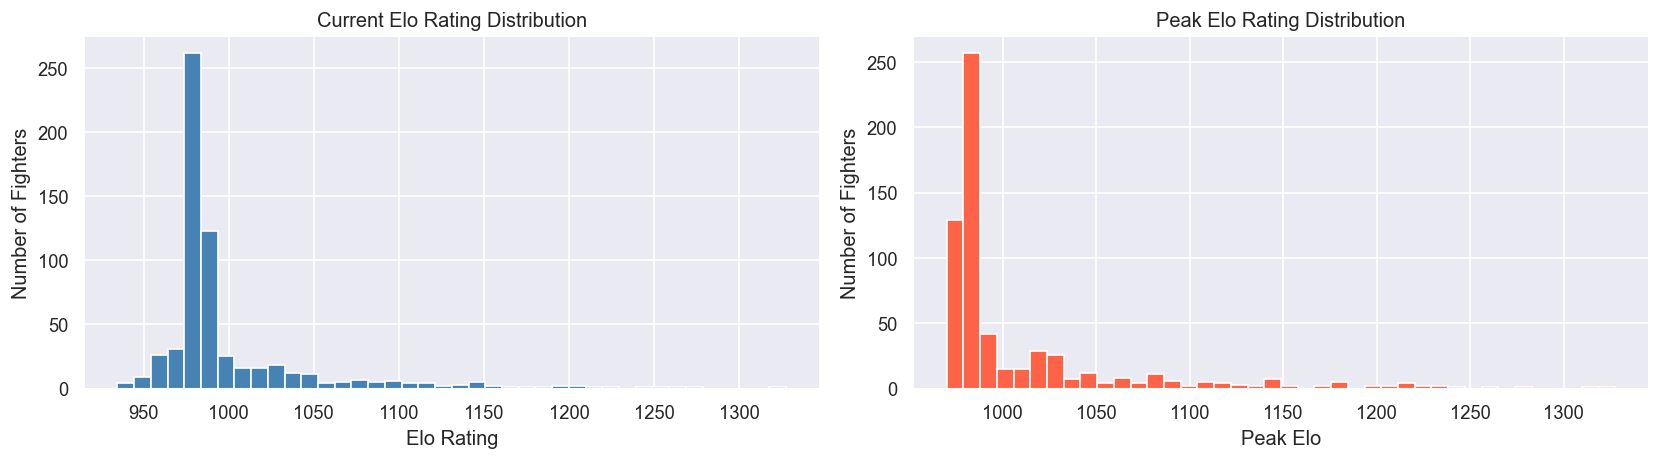

In [12]:
# Elo rating distribution across all fighters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(elo_current['Elo Rating'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Current Elo Rating Distribution')
axes[0].set_xlabel('Elo Rating')
axes[0].set_ylabel('Number of Fighters')

axes[1].hist(elo_peak['Peak Elo'], bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Peak Elo Rating Distribution')
axes[1].set_xlabel('Peak Elo')
axes[1].set_ylabel('Number of Fighters')

plt.tight_layout()
plt.show()

## 4. Elo Engine - Fighter Rating Trajectories

Track how selected fighters' ratings evolved over their careers.

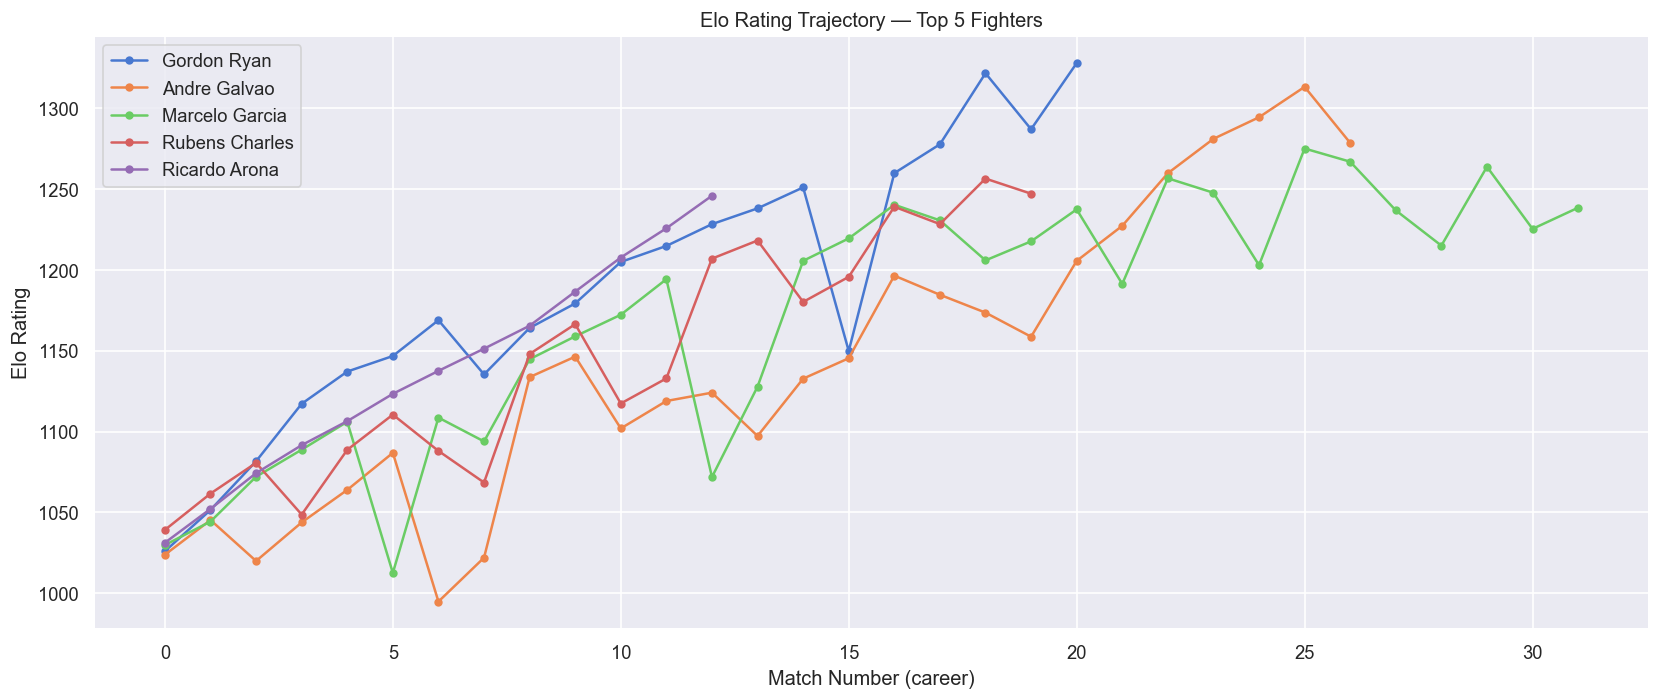

In [13]:
# Change these to any fighters in the dataset
FIGHTERS_TO_TRACK = elo_current.head(5)['Fighter'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for fighter in FIGHTERS_TO_TRACK:
    # Get all matches involving this fighter, in order
    as_winner = elo_matches[elo_matches['winner_name'] == fighter][['year', 'winner_elo_end']].rename(columns={'winner_elo_end': 'rating'})
    as_loser  = elo_matches[elo_matches['loser_name']  == fighter][['year', 'loser_elo_end']].rename(columns={'loser_elo_end': 'rating'})
    trajectory = pd.concat([as_winner, as_loser]).sort_values('year')
    ax.plot(range(len(trajectory)), trajectory['rating'], marker='o', markersize=4, label=fighter)

ax.set_title('Elo Rating Trajectory — Top 5 Fighters')
ax.set_xlabel('Match Number (career)')
ax.set_ylabel('Elo Rating')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Glicko-2 Engine - Top Rankings

In [14]:
print('=== Top 20 Current Glicko-2 Ratings ===')
display(g2_current.head(20))

print('\n=== Top 20 Peak Glicko-2 Ratings ===')
display(g2_peak.head(20))

=== Top 20 Current Glicko-2 Ratings ===


,Fighter,Rating,RD
0,Gordon Ryan,2639.550120,132.85
1,Ricardo Arona,2431.531737,142.21
2,Royler Gracie,2380.821106,179.61
3,Rubens Charles,2340.809848,144.58
4,Rafael Mendes,2318.795771,163.88
5,Marcelo Garcia,2256.026334,123.95
6,Roger Gracie,2234.697127,134.00
7,Kaynan Duarte,2233.320507,193.27
8,Gabrielle Garcia,2231.164800,175.86
9,Amy Campo,2214.696157,250.91



=== Top 20 Peak Glicko-2 Ratings ===


,Fighter,Peak Rating
0,Gordon Ryan,2639.550120
1,Royler Gracie,2484.001720
2,Ricardo Arona,2431.531737
3,Rafael Mendes,2378.054058
4,Gabrielle Garcia,2370.073066
5,Rubens Charles,2340.809848
6,Marcelo Garcia,2288.066362
7,Marcus Almeida,2258.285947
8,Roger Gracie,2234.697127
9,Kaynan Duarte,2233.320507


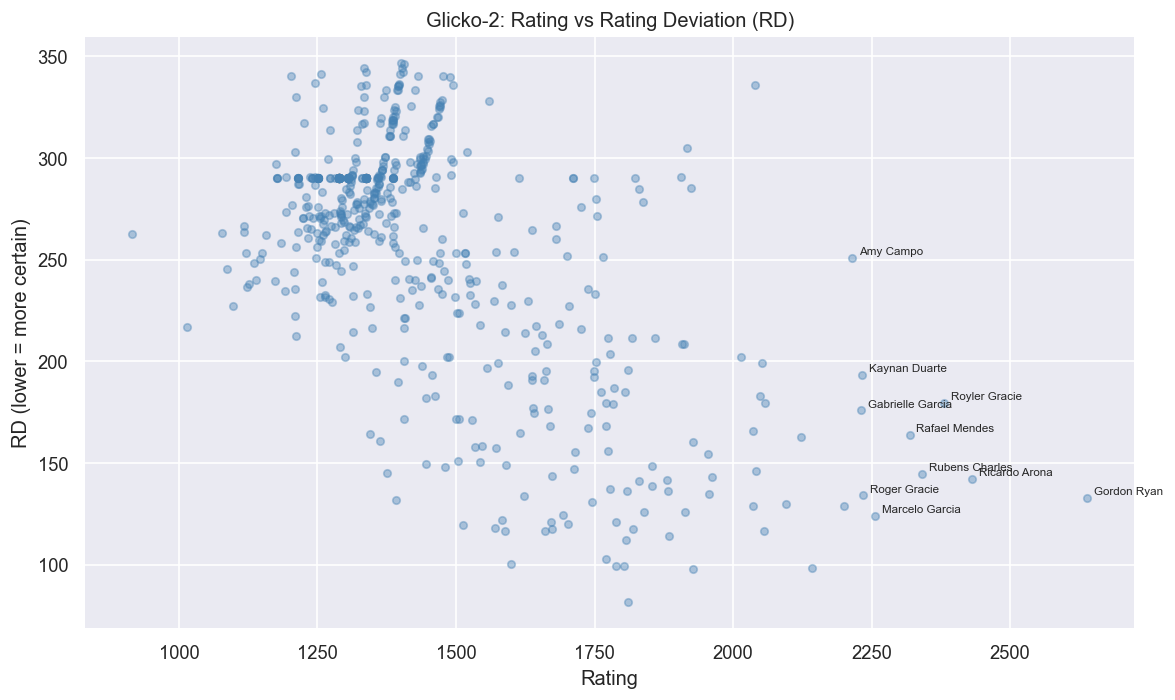

In [15]:
# Rating vs RD scatter - shows who is highly rated but uncertain
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(g2_current['Rating'], g2_current['RD'], alpha=0.4, s=20, color='steelblue')

# Annotate top 10
for _, row in g2_current.head(10).iterrows():
    ax.annotate(row['Fighter'], (row['Rating'], row['RD']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))

ax.set_title('Glicko-2: Rating vs Rating Deviation (RD)')
ax.set_xlabel('Rating')
ax.set_ylabel('RD (lower = more certain)')
plt.tight_layout()
plt.show()

**Reading this chart:** fighters in the bottom-right have high ratings *and* low uncertainty (many matches). Fighters in the top-right are highly rated but with high RD; fewer matches, less confidence in the rating.

## 6. Engine Comparison - Do They Agree?

Both engines should broadly agree on who the best fighters are. We measure this with Spearman rank correlation.

In [16]:
# Merge on fighter name — only fighters present in both
elo_ranked  = elo_current.rename(columns={'Elo Rating': 'elo'}).reset_index().rename(columns={'index': 'elo_rank'})
g2_ranked   = g2_current.rename(columns={'Rating': 'glicko2'}).reset_index().rename(columns={'index': 'g2_rank'})

merged = pd.merge(elo_ranked[['Fighter', 'elo', 'elo_rank']],
                  g2_ranked[['Fighter', 'glicko2', 'g2_rank']],
                  on='Fighter')

corr, pval = spearmanr(merged['elo_rank'], merged['g2_rank'])
print(f'Spearman rank correlation: {corr:.4f}  (p={pval:.2e})')
print(f'Fighters in both rankings: {len(merged)}')

Spearman rank correlation: 0.8962  (p=3.83e-218)
Fighters in both rankings: 614


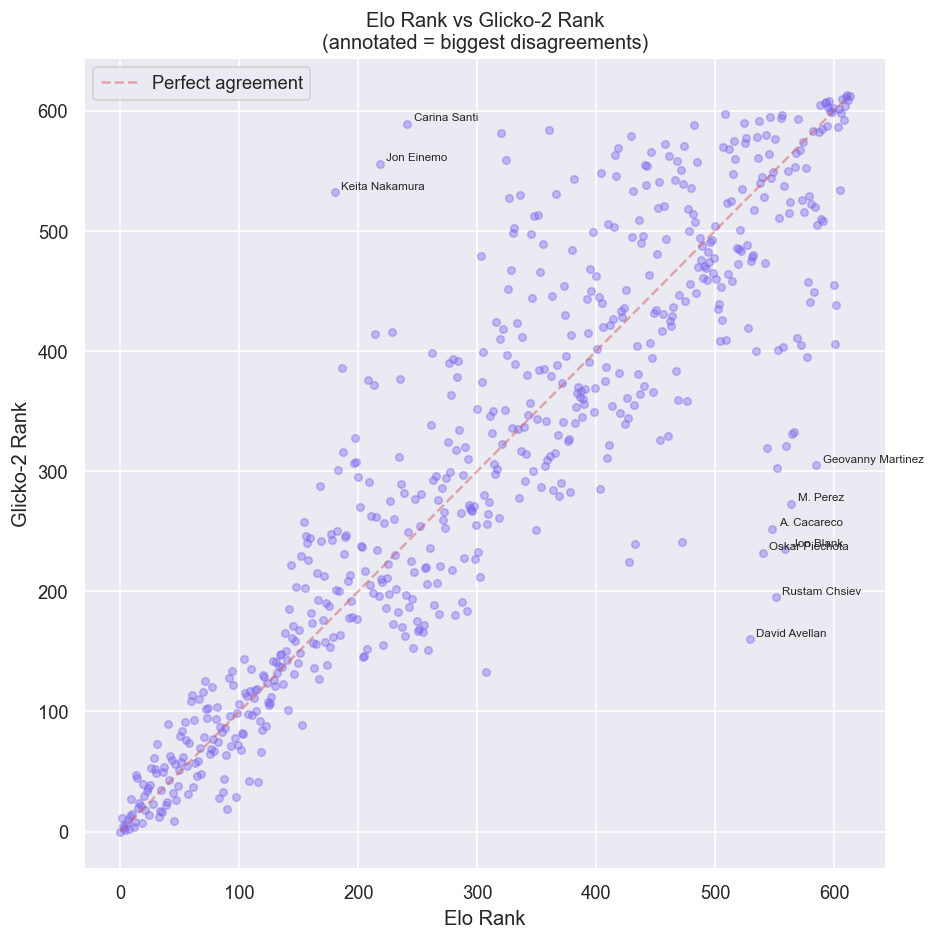

In [17]:
# Scatter: Elo rank vs Glicko-2 rank
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(merged['elo_rank'], merged['g2_rank'], alpha=0.4, s=20, color='mediumslateblue')

# Annotate fighters where the engines disagree the most
merged['rank_diff'] = (merged['elo_rank'] - merged['g2_rank']).abs()
for _, row in merged.nlargest(10, 'rank_diff').iterrows():
    ax.annotate(row['Fighter'], (row['elo_rank'], row['g2_rank']),
                fontsize=7, textcoords='offset points', xytext=(4, 2))

# Diagonal = perfect agreement
lims = [0, merged[['elo_rank', 'g2_rank']].max().max()]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect agreement')

ax.set_title('Elo Rank vs Glicko-2 Rank\n(annotated = biggest disagreements)')
ax.set_xlabel('Elo Rank')
ax.set_ylabel('Glicko-2 Rank')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Fighters where the two engines disagree most
print('=== Biggest ranking disagreements between Elo and Glicko-2 ===')
display(
    merged[['Fighter', 'elo_rank', 'g2_rank', 'rank_diff', 'elo', 'glicko2']]
    .nlargest(20, 'rank_diff')
    .reset_index(drop=True)
)

=== Biggest ranking disagreements between Elo and Glicko-2 ===


,Fighter,elo_rank,g2_rank,rank_diff,elo,glicko2
0,David Avellan,529,160,369,975.50,1479.962594
1,Rustam Chsiev,551,195,356,972.30,1445.469077
2,Keita Nakamura,180,532,352,989.74,1256.612984
3,Carina Santi,241,589,348,985.64,1203.201091
4,Jon Einemo,218,556,338,987.02,1245.256956
5,Jon Blank,559,235,324,968.28,1405.423649
6,Oskar Piechota,540,232,308,974.69,1405.867430
7,A. Cacareco,548,252,296,972.73,1391.687147
8,M. Perez,564,273,291,966.69,1386.263528
9,Geovanny Martinez,585,305,280,960.17,1362.304006


## 7. Peak vs Current Rating - Career Arc

Fighters far below their peak have declined. Fighters near their peak are currently dominant.

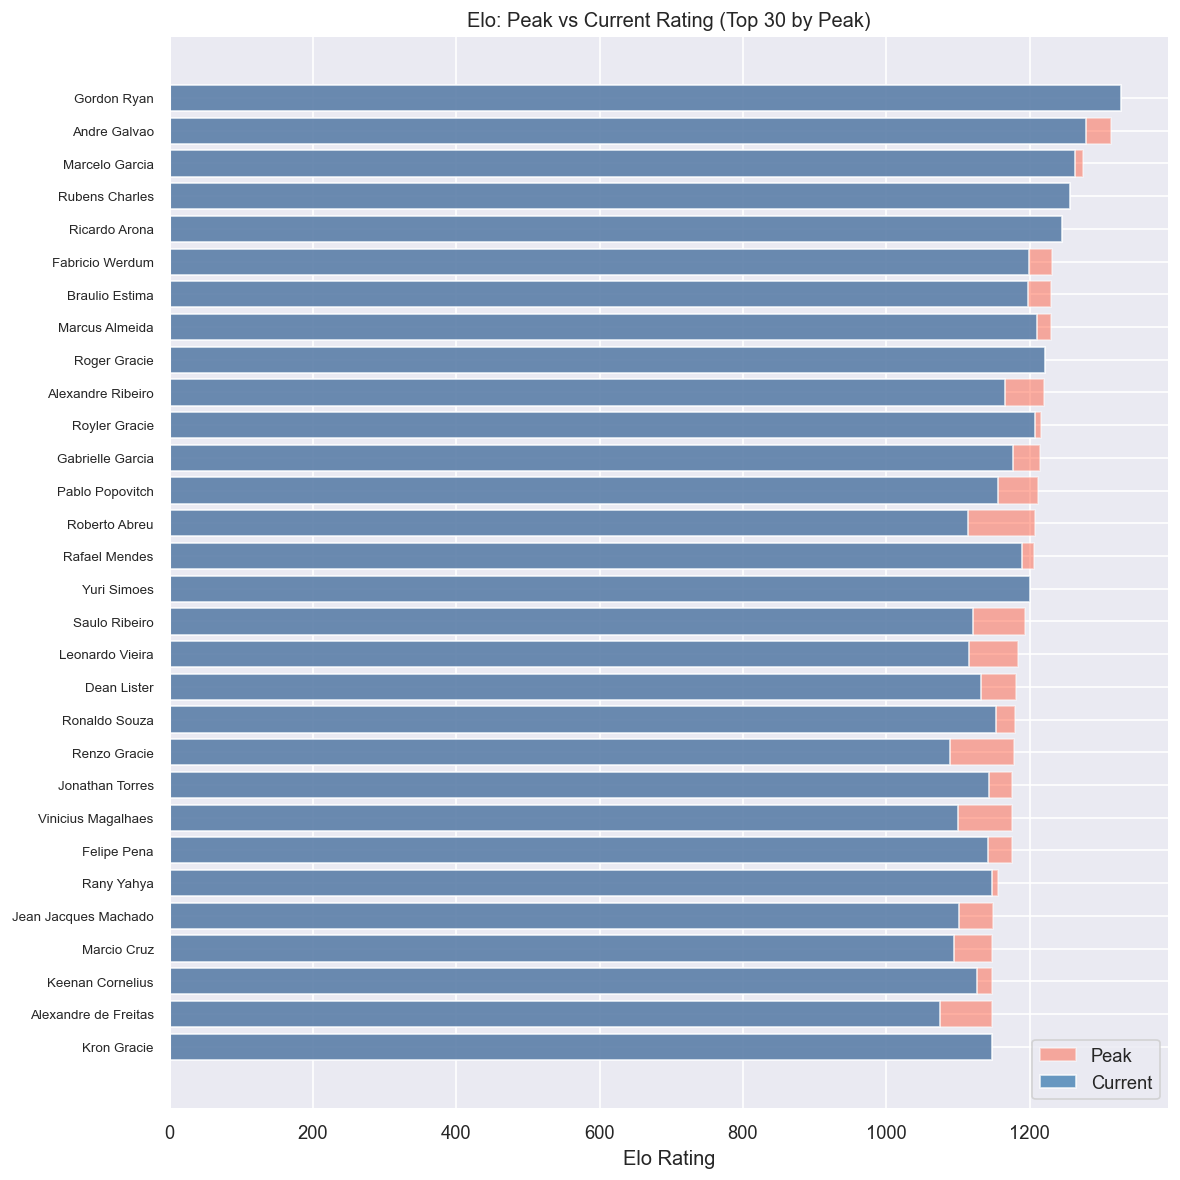

In [19]:
# Elo: peak vs current for top 30 by peak
elo_combined = pd.merge(
    elo_peak.head(30),
    elo_current,
    on='Fighter'
).sort_values('Peak Elo', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
y = range(len(elo_combined))
ax.barh(y, elo_combined['Peak Elo'], color='tomato', alpha=0.5, label='Peak')
ax.barh(y, elo_combined['Elo Rating'], color='steelblue', alpha=0.8, label='Current')
ax.set_yticks(list(y))
ax.set_yticklabels(elo_combined['Fighter'], fontsize=8)
ax.set_title('Elo: Peak vs Current Rating (Top 30 by Peak)')
ax.set_xlabel('Elo Rating')
ax.legend()
plt.tight_layout()
plt.show()

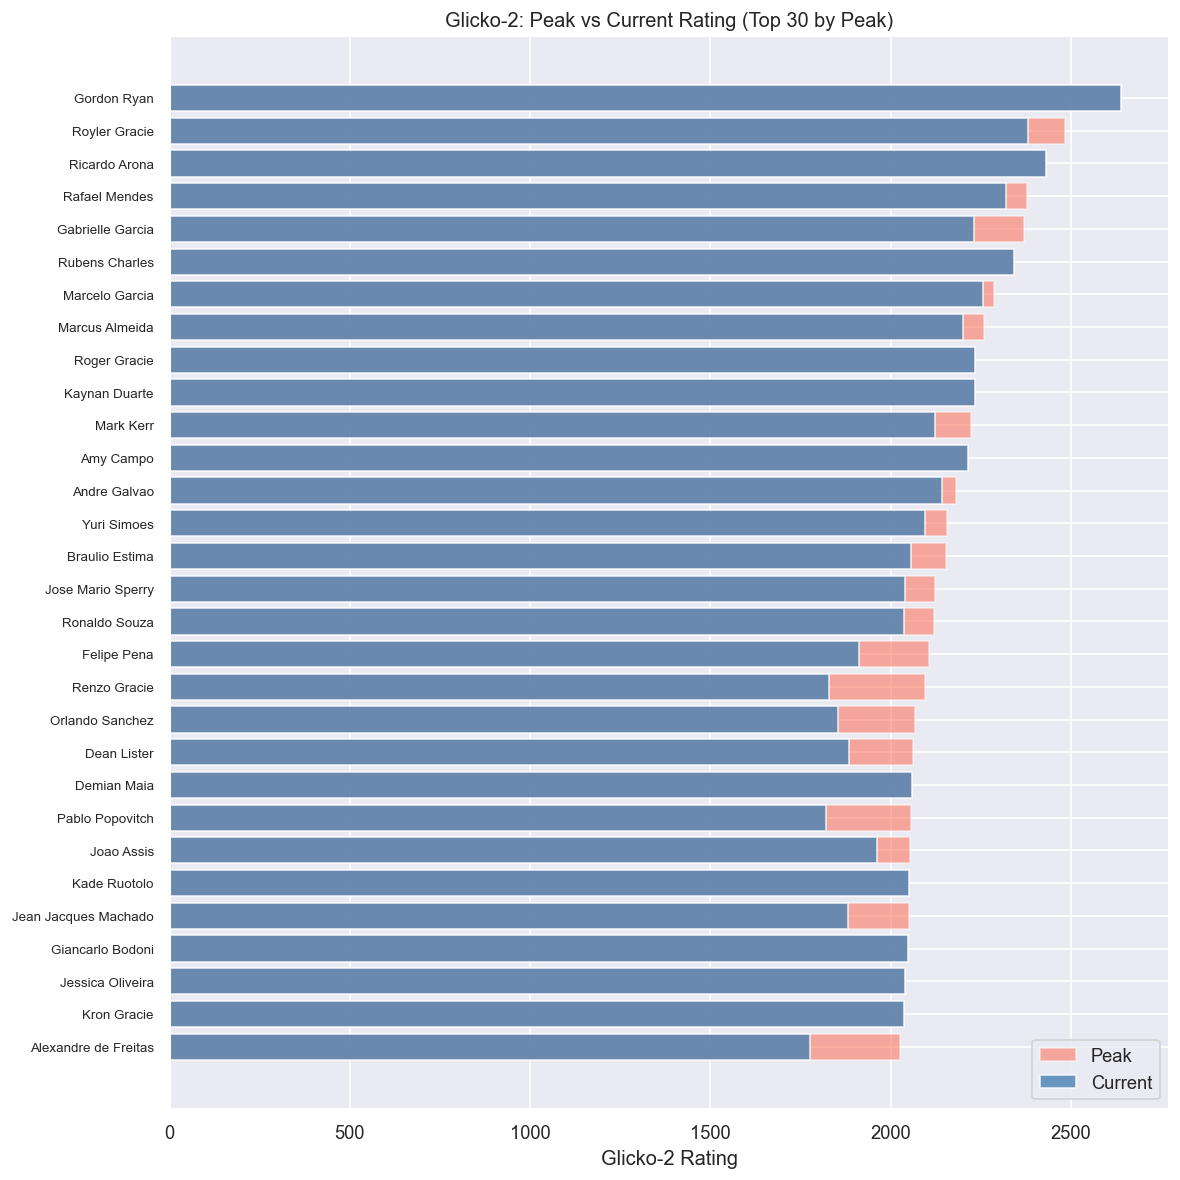

In [20]:
# Glicko-2: same chart
g2_combined = pd.merge(
    g2_peak.head(30),
    g2_current[['Fighter', 'Rating']],
    on='Fighter'
).sort_values('Peak Rating', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
y = range(len(g2_combined))
ax.barh(y, g2_combined['Peak Rating'], color='tomato', alpha=0.5, label='Peak')
ax.barh(y, g2_combined['Rating'], color='steelblue', alpha=0.8, label='Current')
ax.set_yticks(list(y))
ax.set_yticklabels(g2_combined['Fighter'], fontsize=8)
ax.set_title('Glicko-2: Peak vs Current Rating (Top 30 by Peak)')
ax.set_xlabel('Glicko-2 Rating')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Rating Change Per Match

How much does each engine move ratings on average? High variance = more volatile system.

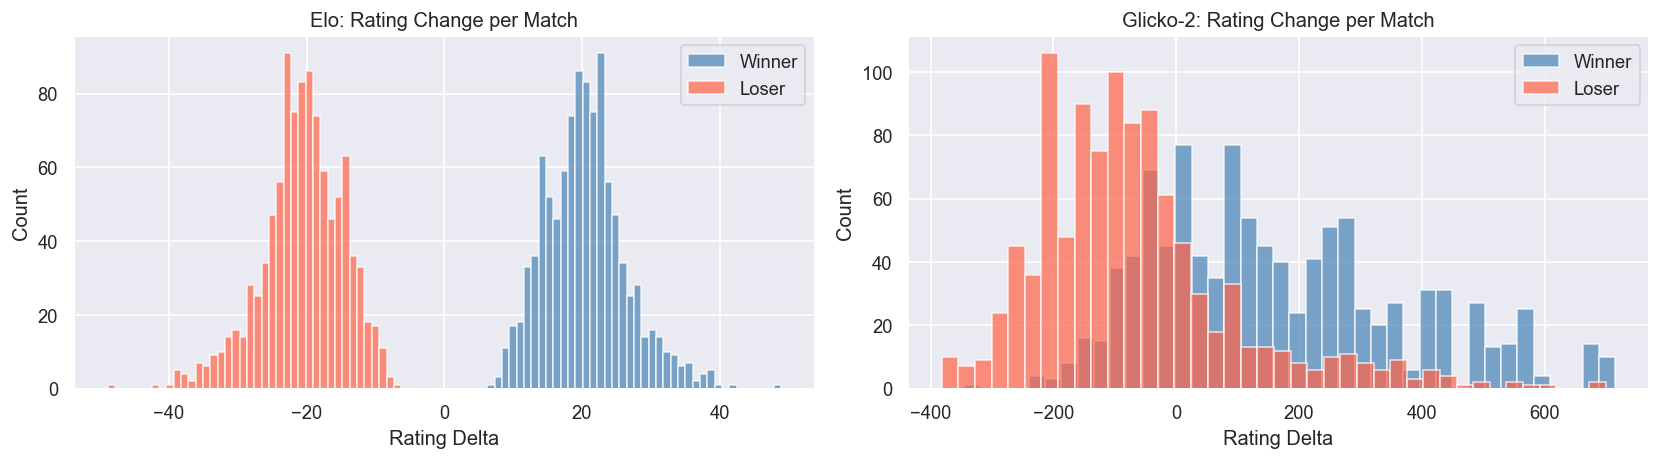

Elo   — mean winner gain: 20.57, std: 5.94
Glicko-2 — mean winner gain: 163.94, std: 204.83


In [21]:
elo_matches['winner_delta'] = elo_matches['winner_elo_end'] - elo_matches['winner_elo_start']
elo_matches['loser_delta']  = elo_matches['loser_elo_end']  - elo_matches['loser_elo_start']

g2_matches['winner_delta']  = g2_matches['winner_rating_end'] - g2_matches['winner_rating_start']
g2_matches['loser_delta']   = g2_matches['loser_rating_end']  - g2_matches['loser_rating_start']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(elo_matches['winner_delta'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='Winner')
axes[0].hist(elo_matches['loser_delta'].dropna(),  bins=40, color='tomato',    edgecolor='white', alpha=0.7, label='Loser')
axes[0].set_title('Elo: Rating Change per Match')
axes[0].set_xlabel('Rating Delta')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(g2_matches['winner_delta'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='Winner')
axes[1].hist(g2_matches['loser_delta'].dropna(),  bins=40, color='tomato',    edgecolor='white', alpha=0.7, label='Loser')
axes[1].set_title('Glicko-2: Rating Change per Match')
axes[1].set_xlabel('Rating Delta')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Elo   — mean winner gain: {:.2f}, std: {:.2f}'.format(elo_matches['winner_delta'].mean(), elo_matches['winner_delta'].std()))
print('Glicko-2 — mean winner gain: {:.2f}, std: {:.2f}'.format(g2_matches['winner_delta'].mean(), g2_matches['winner_delta'].std()))

## 9. Upset Analysis

An upset is when a lower-rated fighter beats a higher-rated one. How often does each engine predict the wrong outcome?

Elo upset rate:      31.5%
Glicko-2 upset rate: 24.6%


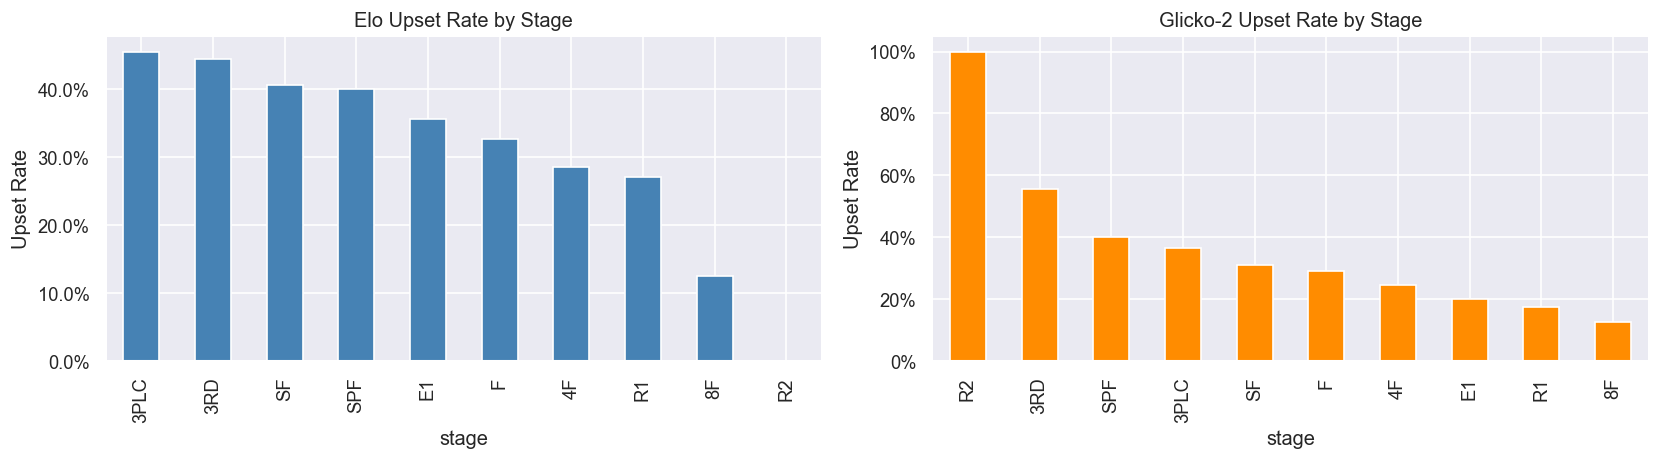

In [22]:
# Elo upsets
elo_matches['elo_upset'] = elo_matches['winner_elo_start'] < elo_matches['loser_elo_start']
elo_upset_rate = elo_matches['elo_upset'].mean()

# Glicko-2 upsets
g2_matches['g2_upset'] = g2_matches['winner_rating_start'] < g2_matches['loser_rating_start']
g2_upset_rate = g2_matches['g2_upset'].mean()

print(f'Elo upset rate:      {elo_upset_rate:.1%}')
print(f'Glicko-2 upset rate: {g2_upset_rate:.1%}')

# Upsets by stage
elo_by_stage = elo_matches.groupby('stage')['elo_upset'].mean().sort_values(ascending=False)
g2_by_stage  = g2_matches.groupby('stage')['g2_upset'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
elo_by_stage.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Elo Upset Rate by Stage')
axes[0].set_ylabel('Upset Rate')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

g2_by_stage.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Glicko-2 Upset Rate by Stage')
axes[1].set_ylabel('Upset Rate')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 10. Summary

| Property | Elo | Glicko-2 |
|---|---|---|
| Update frequency | Per match | Per year (period) |
| Uncertainty modelling | None | RD + volatility |
| Inactivity penalty | None | RD widens over time |
| Rating scale | ~1000 baseline | ~1500 baseline |
| Interpretability | High | Medium |
| Sensitivity to order | Yes (within year) | No (period snapshot) |

**Which to use?**
- Use **Elo** if you want simplicity and per-match granularity.
- Use **Glicko-2** if you want uncertainty-aware rankings - fighters with fewer matches will have higher RD, signalling lower confidence. This is more honest for sparse ADCC data.
- A high Spearman correlation between both means the rankings are consistent and neither engine is broken.